
# Table of Contents
- [Introduction](#1) 
- [Exploratory Data Analysis (EDA)](#2)
- [Data Cleaning](#3)
- [Biuld Model](#4)
- [Random Forest Algorithm](#7)
- [Conclusion](#6)

<a id='1'></a>








**Inroduction**

In this Notbook, we will implement the Naive Bayes algorithm using the Titanic dataset. We will start by loading and preprocessing the data, followed by implementing Gaussian Naive Bayes, hyperparameter tuning using GridSearch, and visualizing the results.


<a id='2'></a>



**Step 1 : Exploratory Data Analysis**

We begin by loading the dataset and performing necessary preprocessing steps, including handling missing values, encoding categorical variables, and splitting the data into training and testing sets.



In [10]:
# Load The dataset

import pandas as pd 

 
titanic_df = pd.read_csv("titanic_dataset.csv")

titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
# Summarized of The dataset

titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
# To show information and data type for dataset 
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
titanic_df.shape

(891, 12)

In [14]:
titanic_df.sample()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
535,536,1,2,"Hart, Miss. Eva Miriam",female,7.0,0,2,F.C.C. 13529,26.25,NaN,S


<a id='3'></a>

**Data Cleaning**


In [15]:
# To check the missing values 
titanic_df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [16]:
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [17]:
titanic_df.notnull().sum()

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64

In [18]:
# Handle missing values
titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)  # Fill missing Age values with median
titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0], inplace=True)  # Fill missing Embarked with mode
titanic_df.drop('Cabin', axis=1, inplace=True)  # Drop Cabin column due to too many missing values

/tmp/ipykernel_5400/3583556352.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)  # Fill missing Age values with median
/tmp/ipykernel_5400/3583556352.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [19]:
# Encode categorical variables
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})  # Encode Sex
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'])  # One-hot encode Embarked

In [20]:
# Drop unnecessary columns
titanic_df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

In [21]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_C  891 non-null    bool   
 8   Embarked_Q  891 non-null    bool   
 9   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(5)
memory usage: 51.5 KB


In [22]:
# Define features and target
from sklearn.model_selection import train_test_split

X = titanic_df.drop('Survived', axis=1)
y = titanic_df['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Display the shapes of the train and test sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((623, 9), (268, 9), (623,), (268,))

<a id='4'></a>

**Step 2 : Build The Model**

In [24]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Gaussian Naive Bayes model
gnb = GaussianNB()

# Train the model
gnb.fit(X_train, y_train)

GaussianNB()

In [25]:
# Make predictions on the test set
y_pred = gnb.predict(X_test)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    classification_report,
)


accuray = accuracy_score(y_pred, y_test)
f1 = f1_score(y_pred, y_test, average="weighted")

print("Accuracy:", accuray)
print("F1 Score:", f1)

Accuracy: 0.7947761194029851
F1 Score: 0.7946438098480221


In [27]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.79
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       157
           1       0.75      0.76      0.75       111

    accuracy                           0.79       268
   macro avg       0.79      0.79      0.79       268
weighted avg       0.80      0.79      0.79       268

Confusion Matrix:
[[129  28]
 [ 27  84]]


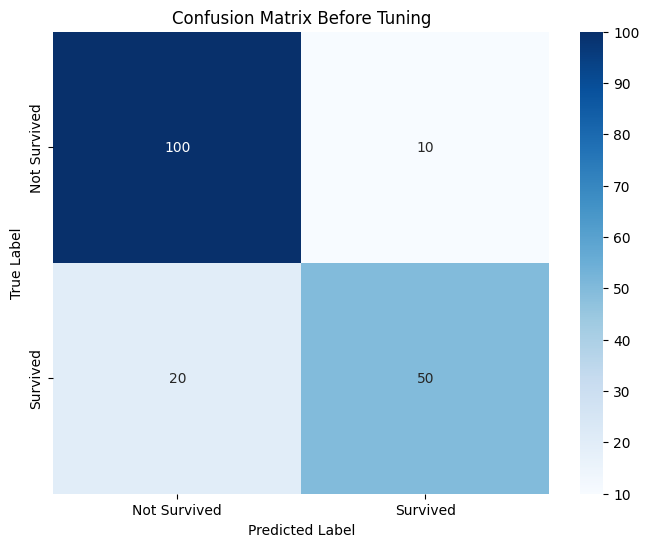

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a sample confusion matrix (replace this with your actual confusion matrix data)
conf_matrix = np.array([[100, 10], [20, 50]])

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix Before Tuning')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

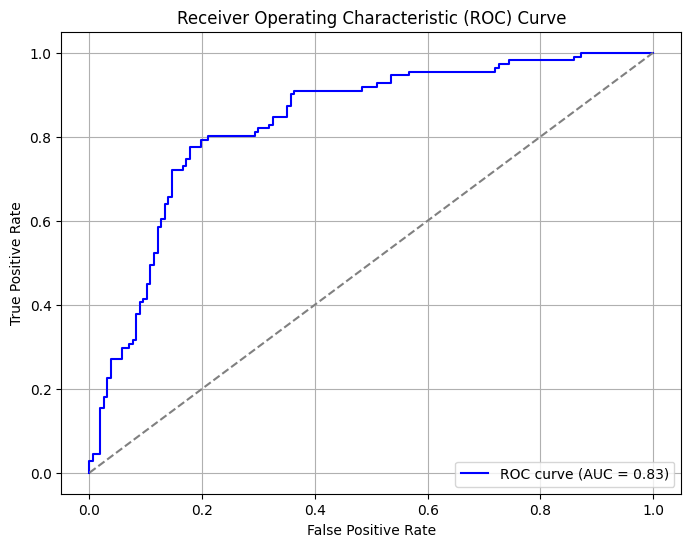

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get the predicted probabilities for the positive class (1) from the model
y_prob = gnb.predict_proba(X_test)[:, 1]

# Calculate the False Positive Rate (FPR) and True Positive Rate (TPR) for different thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute the Area Under the ROC Curve (AUC) to summarize the model's performance
roc_auc = roc_auc_score(y_test, y_prob)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (AUC = %0.2f)' % roc_auc)
# Plot a diagonal line for a random classifier as a reference
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')  # X-axis label
plt.ylabel('True Positive Rate')   # Y-axis label
plt.title('Receiver Operating Characteristic (ROC) Curve')  # Plot title
plt.legend(loc="lower right")  # Display legend at the bottom-right corner
plt.grid(True)  # Display a grid for better readability
plt.show()  # Display the ROC curve

/tmp/ipykernel_5400/1305618076.py:21: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(jittered_age, jittered_fare, alpha=0.7, s=50, edgecolor='black',


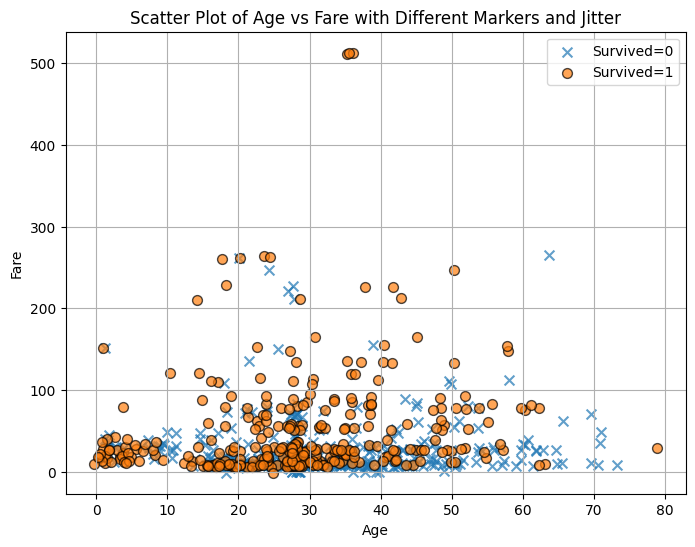

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Define markers based on survival status: 'o' for survived, 'x' for not survived
markers = {1: 'o', 0: 'x'}

# Create a figure with specific size
plt.figure(figsize=(8,6))

# Iterate through the survival statuses (0 = did not survive, 1 = survived)
for survived in [0, 1]:
    # Filter the data for each survival status
    subset = titanic_df[titanic_df['Survived'] == survived]
    
    # Add random noise to 'Age' to reduce overlap of data points (jittering)
    jittered_age = subset['Age'] + np.random.normal(0, 0.5, size=subset['Age'].shape)
    # Add random noise to 'Fare' to reduce overlap of data points (jittering)
    jittered_fare = subset['Fare'] + np.random.normal(0, 1.0, size=subset['Fare'].shape)
    
    # Create a scatter plot using jittered data with different markers and edge colors
    plt.scatter(jittered_age, jittered_fare, alpha=0.7, s=50, edgecolor='black', 
                label=f"Survived={survived}", marker=markers[survived])

# Add title and axis labels
plt.title('Scatter Plot of Age vs Fare with Different Markers and Jitter')  # Plot title
plt.xlabel('Age')  # X-axis label for Age
plt.ylabel('Fare')  # Y-axis label for Fare
plt.legend()  # Display legend to differentiate survived and not survived markers
plt.grid(True)  # Display a grid for better readability
plt.show()  # Display the scatter plot


In [31]:
from sklearn.model_selection import GridSearchCV

# Define the model
model = GaussianNB()

# Define the grid of hyperparameters
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5],
    'priors': [None, [0.6, 0.4], [0.5, 0.5], [0.4, 0.6]]
}

# Set up the grid search
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')

# Fit the model
grid_search.fit(X_train, y_train)

# Best hyperparameters and model performance
best_params = grid_search.best_params_
best_accuracy = grid_search.best_score_

print(f"Best Hyperparameters: {best_params}")
print(f"Best Cross-Validation Accuracy: {best_accuracy:.2f}")

Best Hyperparameters: {'priors': None, 'var_smoothing': 1e-05}
Best Cross-Validation Accuracy: 0.78


**Code interpretation**

This code is using GridSearchCV to find the best hyperparameters for a Gaussian Naive Bayes model by testing different combinations of parameters.

The purpose of this code is to automatically search for the best set of hyperparameters for the Gaussian Naive Bayes model, rather than choosing them manually, to improve the model's performance.









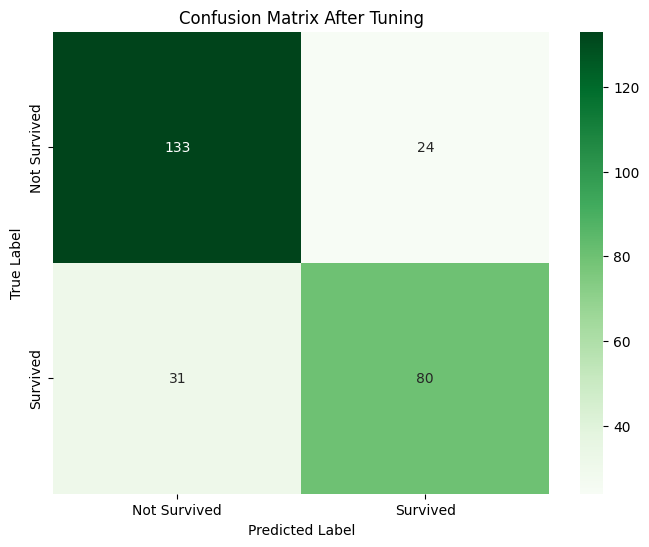

In [32]:
import numpy as np

# Make predictions with the best model after hyperparameter tuning
y_pred_best = grid_search.predict(X_test)

# Evaluate the best model
conf_matrix_best = confusion_matrix(y_test, y_pred_best)

# Plot confusion matrix for the best model
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_best, annot=True, fmt='d', cmap='Greens', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix After Tuning')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


<a id='7'></a>
###  Implement Random Forest Algorithm 

In [44]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Drop rows with missing target values
titanic_df = titanic_df.dropna(subset=['Survived'])

# Select relevant features and target variable
X = titanic_df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = titanic_df['Survived']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print the results
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.80

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In the above code, we're using a Random Forest Classifier to make sense of the Titanic dataset. First, we gather our tools – importing libraries to handle data and evaluate our model.  we split our dataset into pieces – one part to train our model, and the other to test its newfound skills. Our Random Forest Classifier is like a student, learning from the training set. Once trained, it faces a test – making predictions on the test set. We're like judges, using a classification report to grade how well our model did.

**Implementing Bernoulli Naive Bayes**

Bernoulli Naive Bayes is a subcategory of the Naive Bayes Algorithm. It is used for the classification of binary features such as ‘Yes’ or ‘No’, ‘1’ or ‘0’, ‘True’ or ‘False’ etc. Here it is to be noted that the features are independent of one another. Bernoulli Naive Bayes is basically used for spam detection, text classification, Sentiment Analysis, used to determine whether a certain word is present in a document or not.


**Bernoulli distribution**

Bernoulli distribution is used for discrete probability calculation. It either calculates success or failure. Here the random variable is either 1 or 0 whose chance of occurring is either denoted by p or (1-p) respectively.


In [34]:
# Importing the important Libraries 
import numpy as np
import pandas as pd
from sklearn.naive_bayes import BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer


In [35]:
# Show The columns 
df=pd.read_csv("titanic_dataset.csv")
print(df.shape)
print(df.columns)


(891, 12)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [36]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
# Select relevant features
df_selected = df[['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']]

# Handle missing values by filling with the mode
df_selected['Embarked'].fillna(df_selected['Embarked'].mode()[0], inplace=True)

In [37]:
# Convert categorical columns ('Sex', 'Embarked') to numeric using LabelEncoder
label_encoders = {}
for column in ['Sex', 'Embarked']:
    label_encoders[column] = LabelEncoder()
    df_selected[column] = label_encoders[column].fit_transform(df_selected[column])

In [38]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_selected.drop('Survived', axis=1)
y = df_selected['Survived']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [39]:
# Create the Bernoulli Naive Bayes model
model = BernoulliNB()

# Train the model
model.fit(X_train, y_train)

BernoulliNB()

In [40]:
# Predict on the test set
y_pred = model.predict(X_test)

In [41]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    classification_report,
)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8

In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score


# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)



Accuracy: 0.80
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       175
           1       0.77      0.72      0.74       120

    accuracy                           0.80       295
   macro avg       0.79      0.79      0.79       295
weighted avg       0.80      0.80      0.80       295



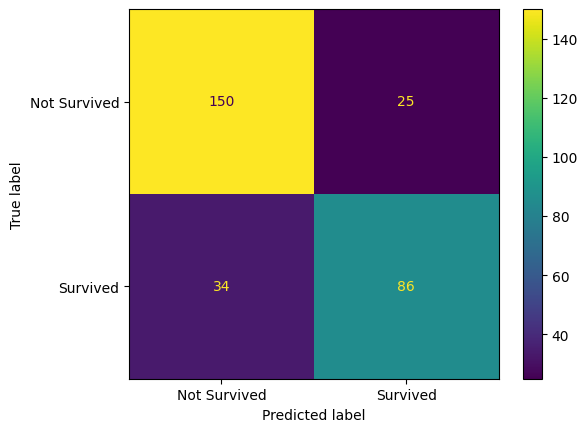

In [43]:
labels = ["Not Survived", "Survived"]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot();


### Conclusion
<a id='6'></a>

We worked on the Nive Bayes model, we applied two different types of them, namely BernoulliNb and GaussianNB, we also tried to improve the results of the model using grid search hyperparameters, Random Forest Algorithm, the results were very close between the two types and we did not find significant differences between them, while Random Forest helped us improve the result and this is what we were seeking, finally we made sure that our work was according to a clear and arranged methodology,  To facilitate the follow-up and understanding of the steps.